In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

from config import *

In [2]:
df = pd.read_parquet("../data/score_dataset_48h.parquet")
df.sample(n=5)

,fen,next_move,played_by_elo,win_pov,games_count,engine_move,delta,fragility_score,variance
500656,r1bqkb1r/ppp1pppp/2n2n2/3p4/3P1B2/4P3/PPP2PPP/...,g1f3,1717,False,6371,g1f3,4.0,0.575269,3812.860912
140379,rn1qkbnr/ppp1pppp/8/3p1b2/3P1B2/8/PPP1PPPP/RN1...,e2e3,1506,False,14679,c2c4,1.0,0.051613,3379.951295
237933,rnbqkb1r/ppp1pppp/5n2/3p4/3P1B2/8/PPP1PPPP/RN1...,e2e3,1675,False,30626,e2e3,-10.0,0.184946,420.257813
236530,rnbqkbnr/ppp1pppp/8/3p4/3P4/8/PPP1PPPP/RNBQKBN...,c1f4,1628,False,145903,c2c4,-31.0,0.022581,640.654900
967187,rnbqkb1r/ppp2ppp/4pn2/3p4/3P1B2/4P3/PPP2PPP/RN...,g1f3,1341,True,2706,g1f3,-3.0,0.306452,9300.207719


In [3]:
scaler = StandardScaler()
df[FEATURES] = scaler.fit_transform(df[FEATURES])

elo_stats = pd.DataFrame(index=ELOS, columns=FEATURES, dtype=float)

for elo in ELOS:
    mask = df["played_by_elo"].between(elo - ELO_DEV, elo + ELO_DEV)
    group = df.loc[mask, FEATURES]
    elo_stats.loc[elo, :] = group.mean().values

elo_stats

,delta,fragility_score,variance
800,-0.129984,0.014318,-0.017033
900,-0.099961,0.053709,0.019951
1000,-0.064009,0.060958,0.016009
1100,-0.056912,0.077921,0.016006
1200,-0.041543,0.059472,0.004645
1300,-0.012225,0.040806,0.003342
1400,0.000158,0.030349,0.002450
1500,0.005428,0.006723,-0.007981
1600,0.023268,-0.003608,-0.013699
1700,0.033840,-0.045932,-0.007953


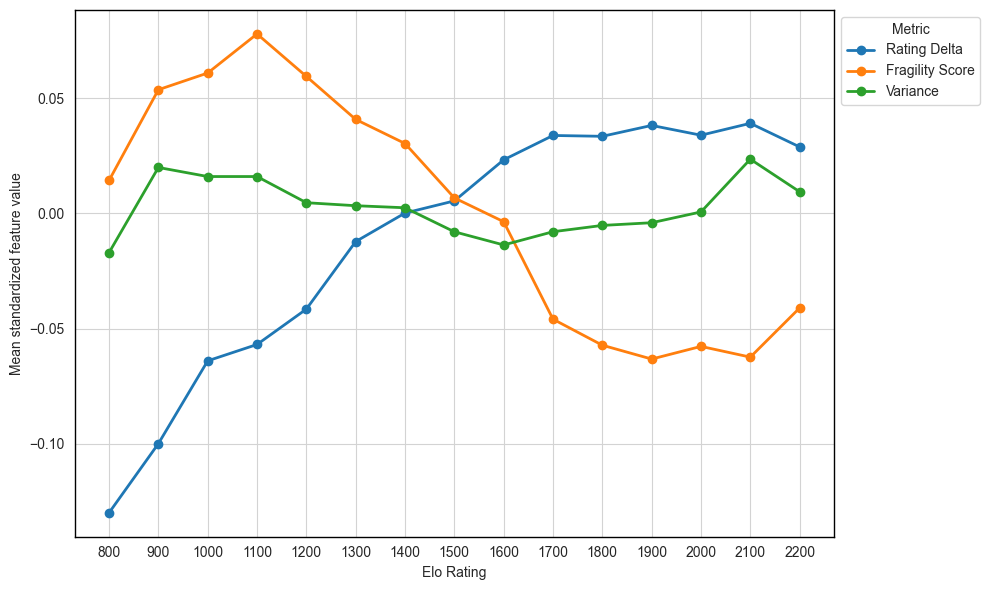

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

for feature in FEATURES:
    y = elo_stats[feature].values
    plt.plot(elo_stats.index, y, marker='o', linewidth=2, label=FEATURE_LABELS.get(feature, feature))

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Mean standardized feature value")
plt.xticks(elo_stats.index)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Metric",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/feature_means.pdf")
plt.show()